# 307.2. 

<div style="max-width:300px; float: left; margin-right: 1em">

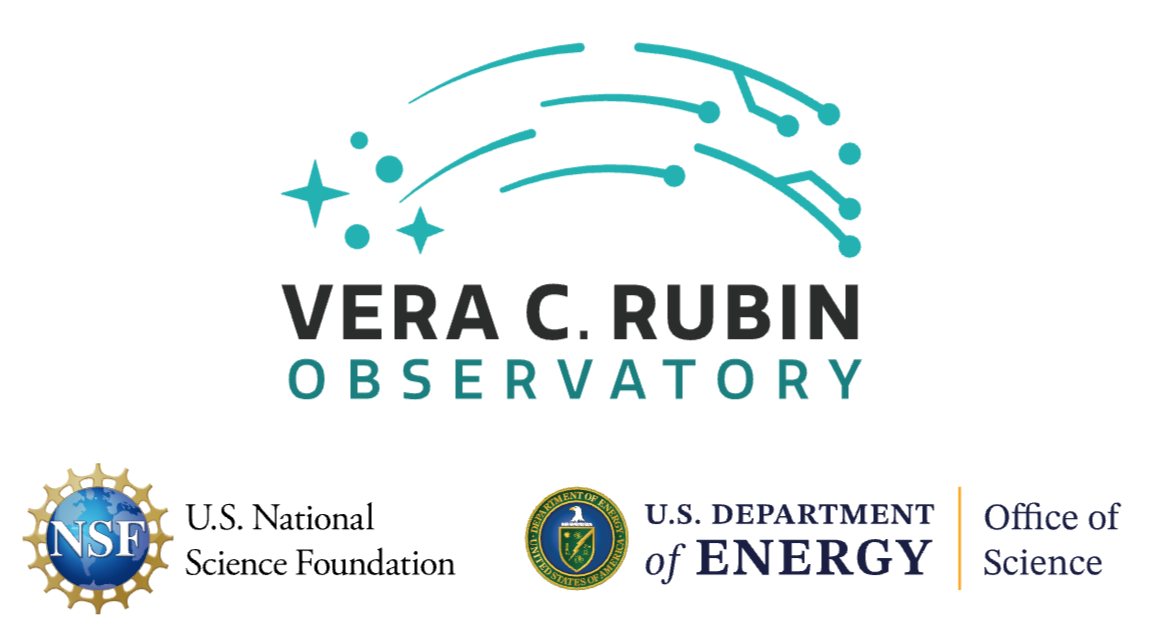

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: <a href="https://dp1.lsst.io/">Data Preview 1</a> <br>
Container Size: Large\
LSST Science Pipelines version: r29.2.0\
Last verified to run: 2026-02-12\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** _Very brief description of notebook's learning objective._

**LSST data products:** `object` table, `DiaObject` table

**Packages:** 

**Credit:** Originally developed by the Rubin Community Science team

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the [Support Category](https://community.lsst.org/c/support) of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

_For **Science Demo** tutorials, more narrative will be needed to describe key scientific concepts and demonstrate their analysis with the Rubin data. Cite or link to any relevant external information, documentation, or papers._

**Related tutorials:** 100 level table upload tutorials. Other 307 notebook.

### 1.1. Import packages

Import `numpy`, a fundamental package for scientific computing with arrays in Python
([numpy.org](https://numpy.org)), and
`matplotlib`, a comprehensive library for data visualization
([matplotlib.org](https://matplotlib.org/); [matplotlib gallery](https://matplotlib.org/stable/gallery/index.html)).

From the `lsst` package, import modules for accessing the Table Access Protocol (TAP) service,
the butler, and image display functions from the LSST Science Pipelines ([pipelines.lsst.io](https://pipelines.lsst.io)).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

from lsst.rsp import get_tap_service, retrieve_query
from lsst.utils.plotting import (get_multiband_plot_colors,
                                 get_multiband_plot_symbols,
                                 get_multiband_plot_linestyles)

### 1.2. Define parameters and functions

Define parameters to use colorblind-friendly colors with `matplotlib`.

In [2]:
plt.style.use('seaborn-v0_8-colorblind')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

Define colors, symbols, and linestyles to represent the six LSST filters, $ugrizy$.

In [3]:
filter_names = ['u', 'g', 'r', 'i', 'z', 'y']
filter_colors_white = get_multiband_plot_colors()
filter_colors_black = get_multiband_plot_colors(dark_background=True)
filter_symbols = get_multiband_plot_symbols()
filter_linestyles = get_multiband_plot_linestyles()

> **Warning:** Due to a bug in `matplotlib`, using `plt.hist` with `histtype='step'` might result in an error when passing the styles in `filter_linestyles`. To overcome this, set the line styles manually using the `patches` object returned by `plt.hist`:
>
> ```python
> _, _, patches = plt.hist(..., histtype='step', ...)
> line_style = filter_linestyles[filter]
> for patch in patches:
>     patch.set_linestyle(line_style)
> ```

Get an instance of the TAP service, and assert that it exists.

In [4]:
service = get_tap_service("tap")
assert service is not None

## 2. Upload a table with coordinates

In [5]:
path = 'Data/'
ut1 = Table.read(path + 'euclid_AGN.csv', format='ascii.csv')

In [6]:
ut1

ra,dec
float64,float64
52.7801,-28.35527
52.7801,-28.35527
52.7801,-28.35527
52.7801,-28.35527
52.7801,-28.35527
52.69935,-28.25595
52.69935,-28.25595
52.69935,-28.25595
52.69935,-28.25595


## 3. Query the DiaObject table

Write the query.

In [7]:
query = """
        SELECT diao.diaObjectId, diao.ra, diao.dec, diao.nDiaSources, 
        diao.g_psfFluxChi2,
        ut1.ra AS ut1_ra, ut1.dec AS ut1_dec,
        DISTANCE(POINT('ICRS', diao.ra, diao.dec), POINT('ICRS', ut1.ra, ut1.dec)) AS distance
        FROM dp1.DiaObject AS diao
        JOIN TAP_UPLOAD.ut1 AS ut1
        WHERE CONTAINS(POINT('ICRS', diao.ra, diao.dec),
        CIRCLE('ICRS', ut1.ra, ut1.dec, 0.00014))=1
        AND diao.nDiaSources > 10
        """

Submit the query as a job to the TAP service. Run the job and wait until the job phase is either "COMPLETED" or "ERROR", then print the job phase and the error message, if applicable.

In [8]:
job = service.submit_job(query, uploads={"ut1": ut1})
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Job phase is COMPLETED


If the status returned was "COMPLETED", execute this cell to retrieve the query results as an astropy table using the to_table method.

In [9]:
dia_objects = job.fetch_result().to_table()
dia_objects.sort('diaObjectId')

Create a list with the diaObjectIds.

In [10]:
dia_object_list = np.unique(dia_objects['diaObjectId'])

#### 5.2 Plot light curve statistics

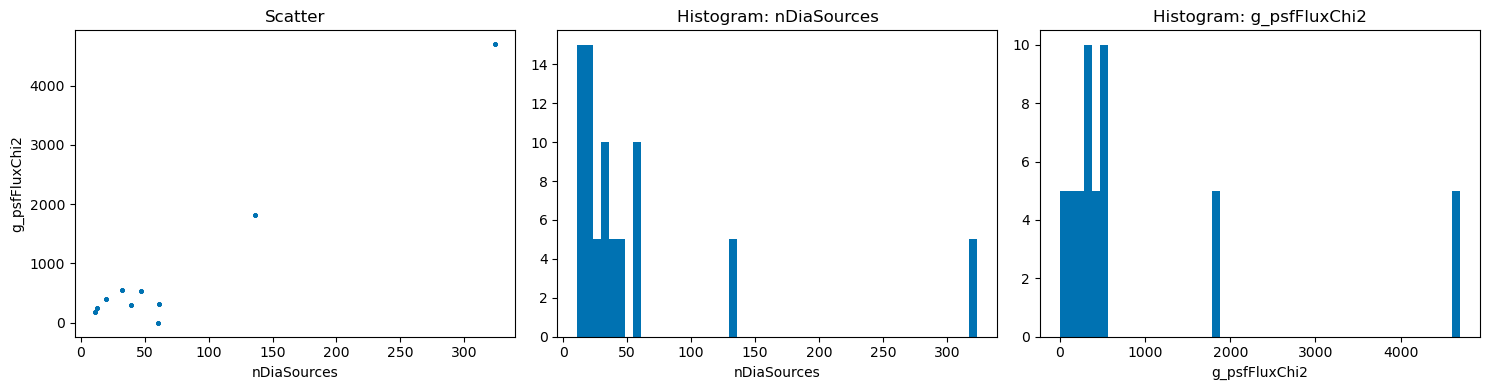

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(dia_objects['nDiaSources'], dia_objects['g_psfFluxChi2'], s=5)
ax[0].set_xlabel("nDiaSources")
ax[0].set_ylabel("g_psfFluxChi2")
ax[0].set_title("Scatter")

# Histogram of nDiaSources
ax[1].hist(dia_objects['nDiaSources'], bins=50)
ax[1].set_xlabel("nDiaSources")
ax[1].set_title("Histogram: nDiaSources")

# Histogram of g_psfFluxChi2
ax[2].hist(dia_objects['g_psfFluxChi2'], bins=50)
ax[2].set_xlabel("g_psfFluxChi2")
ax[2].set_title("Histogram: g_psfFluxChi2")

plt.tight_layout()
plt.show()

## 4. Query for light curves

In [12]:
diaObjectId_list = "(" + ", ".join(str(value) for value in np.unique(dia_objects['diaObjectId'])) + ")"

In [13]:
query = "SELECT fsodo.coord_ra, fsodo.coord_dec, "\
        "fsodo.diaObjectId, fsodo.visit, fsodo.band, "\
        "fsodo.psfFlux, fsodo.psfFluxErr, "\
        "vis.expMidptMJD "\
        "FROM dp1.ForcedSourceOnDiaObject as fsodo "\
        "JOIN dp1.Visit as vis ON vis.visit = fsodo.visit "\
        f"WHERE fsodo.diaObjectId IN {diaObjectId_list}"

In [14]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Job phase is COMPLETED


In [15]:
assert job.phase == 'COMPLETED'
results = job.fetch_result().to_table()

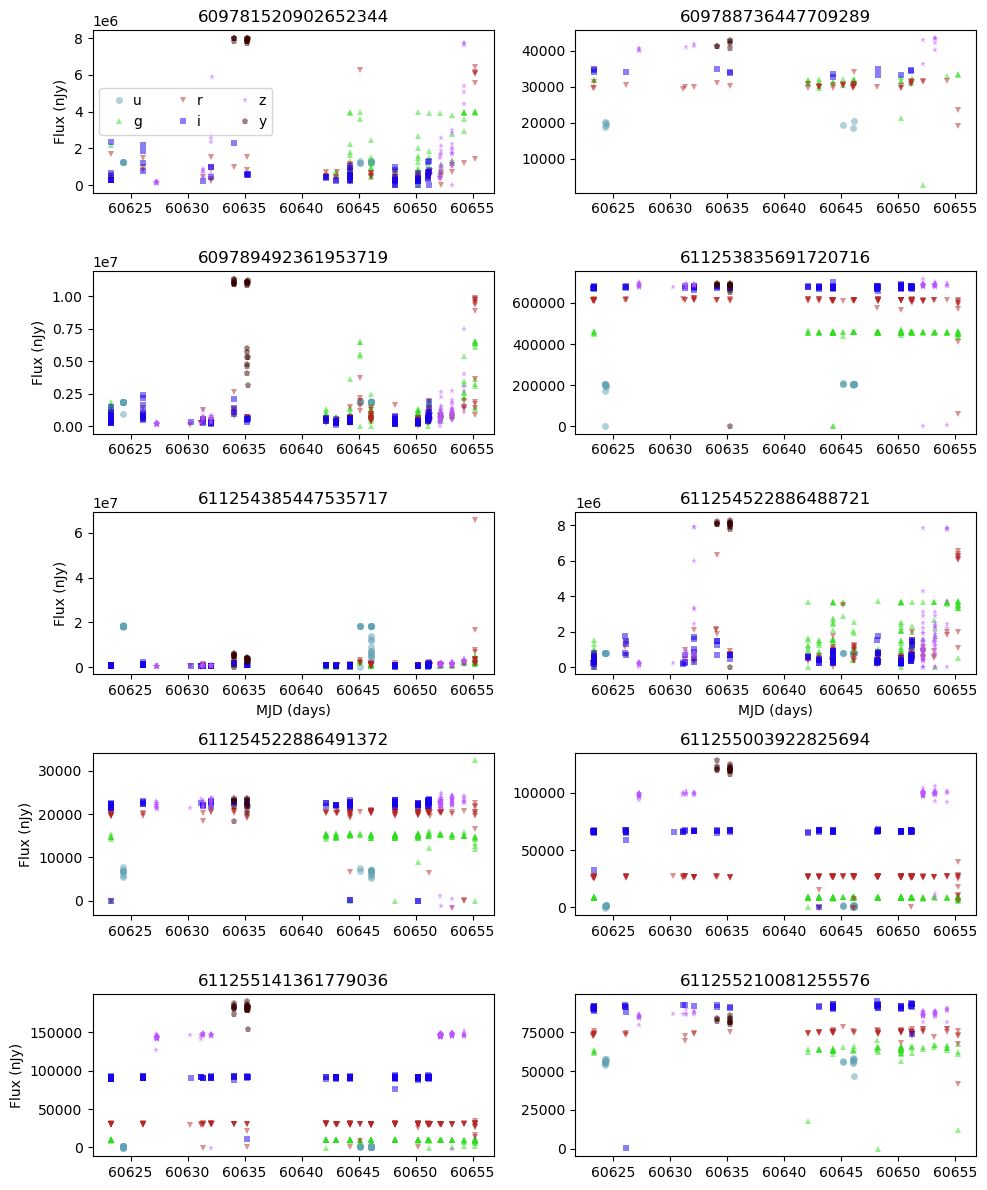

In [16]:
fig, ax = plt.subplots(5, 2, figsize=(10, 12), sharey=False, sharex=False)

unique_dia_obj_id = np.unique(results['diaObjectId'])

x = 0
for i in range(5):
    for j in range(2):
        for f, filt in enumerate(filter_names):
            dx = np.where(results['diaObjectId'] == unique_dia_obj_id[x])
            lc = results[dx]
            fx = np.where(lc['band'] == filt)[0]
            if (i == 0) & (j == 0):
                ax[i, j].plot(lc['expMidptMJD'][fx], lc['psfFlux'][fx],
                              filter_symbols[filt], ms=5, mew=0, alpha=0.5,
                              color=filter_colors_white[filt], label=filt)
            else:
                ax[i, j].plot(lc['expMidptMJD'][fx], lc['psfFlux'][fx],
                              filter_symbols[filt], ms=5, mew=0, alpha=0.5,
                              color=filter_colors_white[filt])
            del dx, fx
        ax[i, j].set_title(unique_dia_obj_id[x])
        del lc
        if (i == 0) & (j == 0):
            ax[i, j].legend(loc='best', ncol=3, handletextpad=0)
        if i == 2:
            ax[i, j].xaxis.set_label_text('MJD (days)')
        if j == 0:
            ax[i, j].yaxis.set_label_text('Flux (nJy)')
        x += 1
plt.tight_layout()
plt.show()